# Hypothesis Testing

In [ ]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## What is a Hypothesis?

If a person claims that:

- coffee makes you awake at night
- sleep makes you taller
- exercise makes you smarter

Or even general statements like:

- people are addicted to smartphones
- people are more literatre

How can we test those claims against reality?

### Definitions: Null vs. Alternative

In every test, we pit two statements against each other:

1. **Null Hypothesis ($H_0$):** The "status quo" or "no effect" statement. It assumes that any observed difference in your data is due to random sampling error (chance) rather than a true effect.
2. **Alternative Hypothesis ($H_a$ or $H_1$):** The statement you are trying to find evidence for. It claims there is a real effect, a difference, or a relationship.

### Anecdotal Evidence

**Anecdotal evidence** is information based on personal accounts, individual stories, or isolated incidents rather than on systematic data or scientific investigation.

Consider the following possible responses to the three research questions:

1. **A man on the news** got mercury poisoning from eating swordfish, so the average mercury concentration in swordfish must be dangerously high.
2. **I met two students** who took more than 7 years to graduate from Duke, so it must take longer to graduate at Duke than at many other colleges.
3. **My friend’s dad** had a heart attack and died after they gave him a new heart disease drug, so the drug must not work.

To put this to the test, we formulate both the null and the alternative hypothesis, and specify the parameter we would need to measure.

For the mercury case: We need to compare the mean mercury level across a large sample of swordfish against the FDA safety threshold (typically 1.0 ppm).

For the graduation case: We compare the distribution of graduation rates at Duke against the national average for 4-year private institutions.

For the medical drug case: In a clinical trial, some patients in the treatment group will inevitably die. We must test if the survival rate of those taking the drug is statistically higher than the survival rate of those in a control group (placebo).

The table following shows how this formulation compares:

| **Example**    | **H0​ (Null Hypothesis)**                   | **Ha​ (Alternative Hypothesis)**            | **Parameter of Interest**     |
| -------------- | ------------------------------------------- | ------------------------------------------- | ----------------------------- |
| **Mercury**    | Mean mercury $\le$ 1.0 ppm.                 | Mean mercury $>$ 1.0 ppm.                   | $\mu$ (Average Concentration) |
| **Duke Grad**  | Duke grad rate $\le$ National Avg.          | Duke grad rate $>$ National Avg.            | $p$ (Proportion of Graduates) |
| **Heart Drug** | Death rate (Drug) $=$ Death rate (Placebo). | Death rate (Drug) $<$ Death rate (Placebo). | $p$ (Survival Probability)    |

## Statistical Tests

Statisticians have developed many methods of testing such hypothesis, based on two factors:

Question we're trying to answer

1. significant difference in one variable? (t-test)
2. association between two categorical variables? (Chi-square)
3. association between two numerical variables? (Pearon's correlation coefficient)

## Testing for Difference: T-tests

We'll start with the first: **just difference**.

![](./assets/t-test.png)

### Case 0: Compare a Sample Against the Population

I intentionally numbered this as *Case Zero* to indicate that there is: **only one sample**.

In reality, this usually means we are making a **comparison against a historic or global value**. Examples:

- To compare the average height of a group of students to the average height of the general population.
- To compare the average IQ of a group of people to the average IQ of the general population.
- To compare the average cholesterol levels of a group of people to the recommended cholesterol levels.

### Case 1: Compare Independent Samples

They are two different groups of people:

- **Control group** takes a placebo drug (fake)
- **Treatment group** takes the real drug

### Case 2: Paired Samples

There are two cases for paired samples:

1. One group: usually looking for **comparison**
2. Two paired groups: usually seeking **relationship**

It is as follows ..

#### Case 2.1: One group, but two measurements

A group with the intervention and a group without the intervention:
 
 1. **Same measurement**, twice on the same group:
     - Grip strength — before vs. after eating spinach
     - Quiz scores — iPad notes vs. paper notes
     - Performance — with afternoon nap vs. without it
 2. **Two measurements**, on the same group:
     - Temperature under right armpit and under left armpit
     - BMI and Systolic Blood Pressure

#### Case 2.2 Two groups with natural pairing

Two groups where each record (sample) in the 1st group is naturally paired with a record (sample) in the 2nd group. For instance: 

   - twins (one in group A and one in group B)
   - husband-wife (one in group A and one in group B)
   - mother-baby (one in group A and one in group B)

## Examples

### Case 0: Hypothesis $H_1$: the average height of NBA player is higher than the average height of the general population

In [ ]:
# Source NBA Heights: https://github.com/simonwarchol/NBA-Height-Weight/blob/master/CSVs/total.csv
nba = pd.read_csv('./data/nba/nba_heights.csv')
nba.describe()

,h_meters,h_in
count,435.000000,435.000000
mean,2.012483,79.209195
std,0.090078,3.573444
min,1.750000,69.000000
25%,1.960000,77.000000
50%,2.030000,80.000000
75%,2.080000,82.000000
max,2.290000,90.000000


In [ ]:
# Source Human Heights: https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset
humans = pd.read_csv('./data/nba/SOCR-HeightWeight.csv')
humans.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


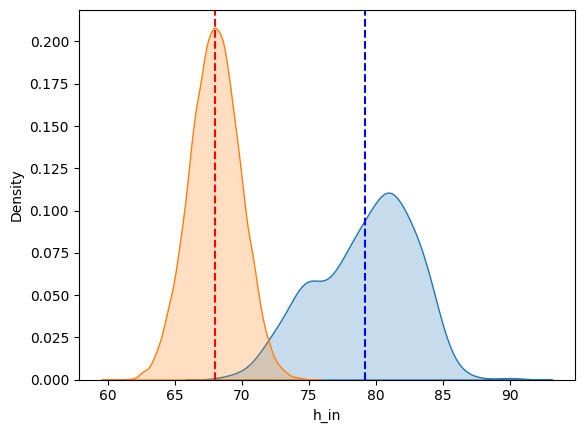

In [5]:
# plot smooth kde distribution of body mass for two sexes overlapping
sns.kdeplot(nba, x='h_in', fill=True)
sns.kdeplot(humans, x='Height(Inches)', fill=True)

# vertical line at the mean of the height for both
plt.axvline(humans['Height(Inches)'].mean(), color='red', linestyle='--')
plt.axvline(nba['h_in'].mean(), color='blue', linestyle='--')

In [8]:
# significance level
alpha = 0.05

# 1 sample t-test
t_statistic, p_value = stats.ttest_1samp(
    nba['h_in'],
    humans['Height(Inches)'].mean(),
    alternative="greater",
)

# Display the results in a table
pd.DataFrame({
    't-statistic': [t_statistic],
    'p-value': [p_value],
    'significant': [p_value <= alpha]
}).T

,0
t-statistic,65.463443
p-value,0.0
significant,True


In [ ]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
# drop na
penguins.dropna(inplace=True)

### Case 1: Hypothesis $H_2$: male penguins weigh more than female penguins

Let's look at the boxplot:

<Axes: ylabel='body_mass_g'>

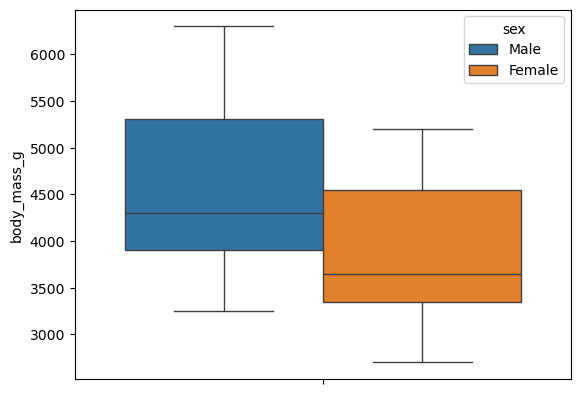

In [ ]:
sns.boxplot(penguins, y='body_mass_g', hue='sex')

Let's look at the density plot:

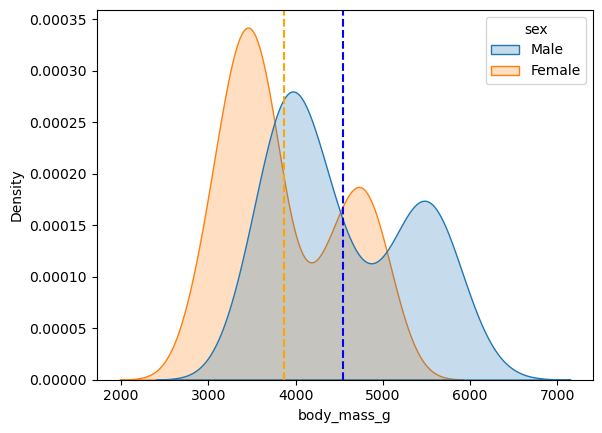

In [ ]:
# plot smooth kde distribution of body mass for two sexes overlapping
sns.kdeplot(penguins, x='body_mass_g', hue='sex', fill=True)

# vertical line at the mean of the body mass for male and another for female
plt.axvline(penguins.loc[penguins['sex'] == 'Male']['body_mass_g'].mean(), color='blue', linestyle='--')
plt.axvline(penguins.loc[penguins['sex'] == 'Female']['body_mass_g'].mean(), color='orange', linestyle='--')

In [ ]:
# significance level
alpha = 0.05

# two-sample t-test
t_statistic, p_value = stats.ttest_ind(
    penguins.loc[penguins["sex"] == "Male", 'body_mass_g'],
    penguins.loc[penguins["sex"] == "Female", 'body_mass_g'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 8.541720337994516
p-value: 2.448623375798112e-16
significant!


### Case 2.1: Hypothesis $H_3$: smokers give higher tips than non-smokers

In [ ]:
import seaborn as sns

tips = sns.load_dataset('tips')
tips.dropna(inplace=True)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Let's look at the box plot:

<Axes: ylabel='tip'>

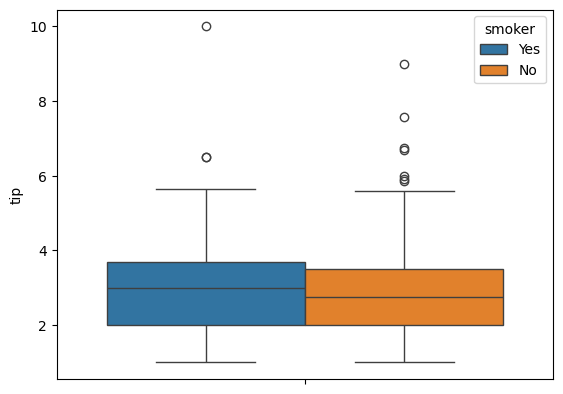

In [ ]:
sns.boxplot(tips, y='tip', hue='smoker')

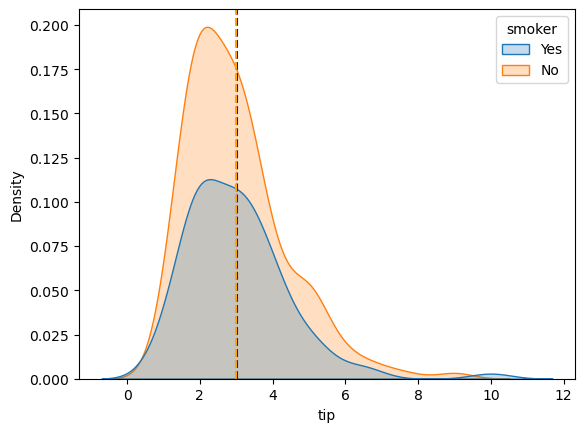

In [ ]:
# plot smooth kde distribution of tips for two groups overlapping
sns.kdeplot(tips, x='tip', hue='smoker', fill=True)

# vertical line at the mean of the tips for smokers and another for non-smokers
plt.axvline(tips.loc[tips['smoker'] == 'Yes']['tip'].mean(), color='blue', linestyle='--')
plt.axvline(tips.loc[tips['smoker'] == 'No']['tip'].mean(), color='orange', linestyle='--')

In [3]:
from scipy import stats

# significance level
alpha = 0.05

# two-sample t-test
t_statistic, p_value = stats.ttest_ind(
    tips.loc[tips["smoker"] == "Yes", 'tip'],
    tips.loc[tips["smoker"] == "No", 'tip'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 0.09222805186888201
p-value: 0.4632965761122488
not enough evidence


### Case 2.1: Hypothesis $H_4$: spinach increases grip strength

Statistical test: Two paired samples (one group, measurement twice)

In [ ]:
# Determine significance level
alpha = 0.05

grip = pd.DataFrame({
    "before": [50, 52, 55, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72],
    "after": [60, 68, 50, 55, 59, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72, 73, 75, 76, 77, 78],
})

# two-sample, related, t-test
t_statistic, p_value = stats.ttest_rel(
    grip['after'],
    grip['before'],
    alternative="greater",
)

print(f"t-statistic: {t_statistic}")
print(f"p-value: {p_value}")
print("significant!" if p_value <= alpha else "not enough evidence")

t-statistic: 6.907558493188381
p-value: 6.898776102555169e-07
significant!


In [74]:
grip.describe()

,before,after
count,20.00000,20.000000
mean,60.60000,66.450000
std,6.26099,7.500702
min,50.00000,50.000000
25%,55.75000,61.750000
50%,60.50000,66.500000
75%,65.25000,72.250000
max,72.00000,78.000000


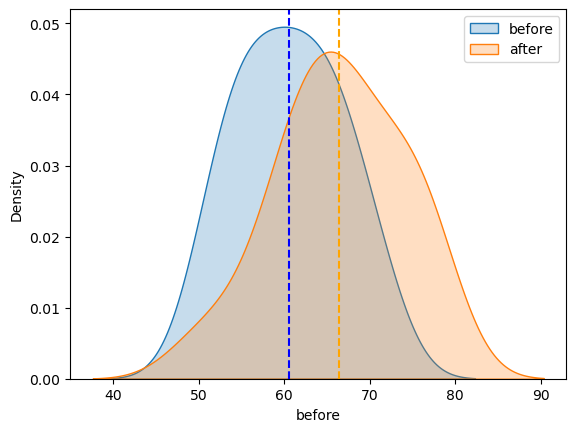

In [ ]:
# plot smooth kde distribution of body mass for two sexes overlapping
ax = sns.kdeplot(grip, x='before', fill=True)
sns.kdeplot(grip, x='after', fill=True, ax=ax)

# legend
plt.legend(['before', 'after'])

# vertical line at the mean of before and after
plt.axvline(grip['before'].mean(), color='blue', linestyle='--')
plt.axvline(grip['after'].mean(), color='orange', linestyle='--')

## One-way ANOVA and Tukey HSD

**An ANOVA (Analysis of Variance**) is a statistical method used to determine if there are statistically significant differences between the means of three or more independent groups.

While a t-test is used to compare the means of exactly two groups, the ANOVA is the "heavy lifter" used when your categorical variable has multiple levels. Example:

1. comparing three different dosages of a drug (10ml, 20ml, and 30ml)
2. or four different studying methods (Flash-cards, Rereding, Practice Tests, and Retrieval)

You might wonder: "Why not just run three separate t-tests to compare Group A vs. B, B vs. C, and A vs. C?"

The answer is **Type I Error (False Positives)**. Every time you run a statistical test, there is usually a 5% chance ($\alpha = 0.05$) of finding a "significant" result purely by luck. If you run many tests, those 5% chances add up.

- **1 test:** 5% risk of error.
- **3 tests:** ~14% risk of error.
- **ANOVA** allows you to test all groups at once while keeping that total risk at 5%.

If you get a significant result, you know that "at least one group is different," but you don't know if Group A is better than B, or if C is the only outlier. To find out exactly which groups differ, you must run a Post-Hoc Test (like the Tukey HSD).

As such, we will only show **Tukey’s HSD (Honestly Significant Difference)**. It tells you which specific pairs are different while controlling for the increased risk of false positives.


#### Hypothesis $H_5$: weights of penguins across species do differ

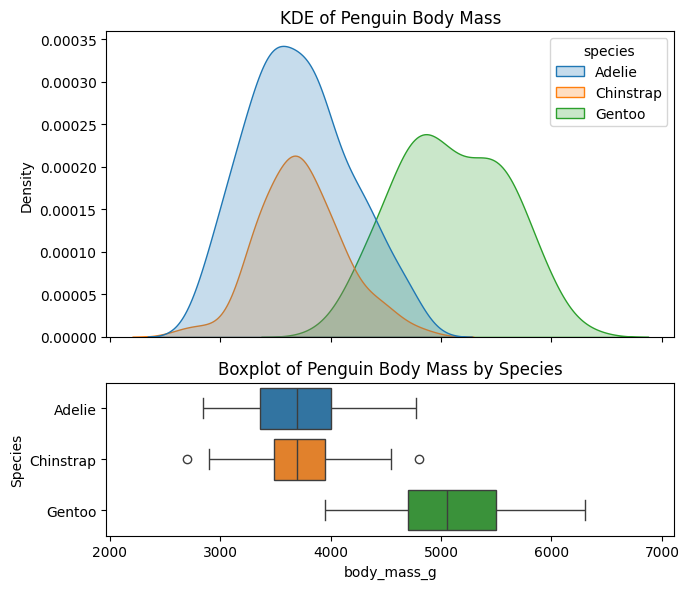

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make two plots sharing the x-axis: one kde, one boxplot
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(7,6), gridspec_kw={'height_ratios': [2, 1]})

sns.kdeplot(penguins, x='body_mass_g', hue='species', fill=True, ax=ax1)
ax1.set(title='KDE of Penguin Body Mass', ylabel='Density')

sns.boxplot(penguins, x='body_mass_g', y='species', orient='h', hue='species', ax=ax2)
ax2.set(title='Boxplot of Penguin Body Mass by Species', xlabel='body_mass_g', ylabel='Species')

plt.tight_layout();

In [2]:
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)

alpha = 0.05

# Use pairwise_tukeyhsd for post-hoc analysis across species
tukey = pairwise_tukeyhsd(endog=penguins['body_mass_g'],
                          groups=penguins['species'],
                          alpha=alpha)

print(tukey)
print("significant!" if (tukey.reject.any()) else "not enough evidence")

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------
significant!


## Categorical Association

### Chi-squared ($\chi^2$) Test

- The **Chi-squared test** is used to test for **association between two categorical variables**.
- However, it doesn't quantify how strong this association is.

#### Hypothesis $H_6$: smoking (yes/no) is associated with time of visit (lunch/dinner)

In [ ]:
# Load the tips dataset from Seaborn
tips = sns.load_dataset("tips")
# tips.dropna(inplace=True)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [16]:
# Create a contingency table of the smoker and time variables
contingency_table = pd.crosstab(
    columns=tips["smoker"],
    index=tips["time"],
    values=tips["tip"],
    aggfunc="count"
)
contingency_table

smoker,Yes,No
time,,
Lunch,23,45
Dinner,70,106


In [17]:
contingency_table.sum().sum()

244

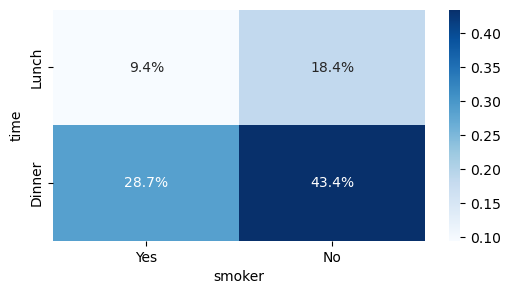

In [18]:
plt.figure(figsize=(6, 3))
normalized_table = contingency_table / contingency_table.sum().sum()
sns.heatmap(data=normalized_table, annot=True, cmap="Blues", fmt=".1%");

In [ ]:
# significance level
alpha = 0.05

# Perform the chi-squared test
result = stats.chi2_contingency(contingency_table)

print(f"p-value: {result.pvalue}")
print("significant!" if result.pvalue <= alpha else "not enough evidence")

p-value: 0.4771485672079724
nope


#### Hypothesis $H_7$: sex is associated with occupation

In [1]:
import pandas as pd

# URL for the UCI Adult dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Define column names as they are not in the raw file
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 
    'marital-status', 'occupation', 'relationship', 'race', 'sex', 
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load data, stripping whitespace and handling '?' as NaN
df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values='?')

# Drop rows with missing occupation data for a clean test
df = df.dropna(subset=['occupation'])

In [4]:
# Create a contingency table to analyze the association between sex and occupation

occupation_sex = pd.crosstab(df['occupation'], df['sex'])
occupation_sex

sex,Female,Male
occupation,,
Adm-clerical,2537,1233
Armed-Forces,0,9
Craft-repair,222,3877
Exec-managerial,1159,2907
Farming-fishing,65,929
Handlers-cleaners,164,1206
Machine-op-inspct,550,1452
Other-service,1800,1495
Priv-house-serv,141,8


In [6]:
occupation_sex.sum().sum()

np.int64(30718)

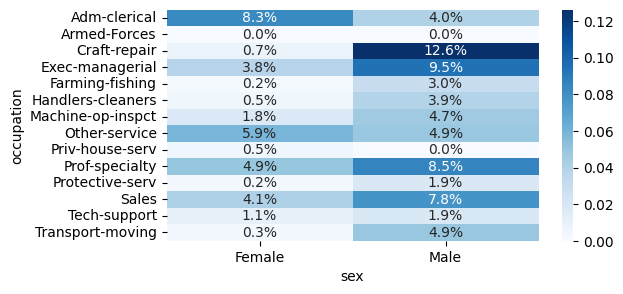

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))
normalized_table = occupation_sex / occupation_sex.sum().sum()
sns.heatmap(data=normalized_table, annot=True, cmap="Blues", fmt=".1%");

In [10]:
from scipy import stats

# significance level
alpha = 0.05

# Perform the chi-squared test
result = stats.chi2_contingency(occupation_sex)

print(f"p-value: {result.pvalue}")
print("significant!" if result.pvalue <= alpha else "not enough evidence")

p-value: 0.0
significant!
